# Exploratory Data Analysis — Room 3.9

This notebook presents the exploratory data analysis (EDA) of the final integrated dataset for Room 3.9.

The analysis includes dataset validation, descriptive statistics, indoor air quality characteristics, people-counter activity, sensor behavior, temporal patterns, and relationships among the main environmental and occupancy-related variables.

In [1]:
# IMPORTS AND NOTEBOOK CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

# Plot configuration
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# Pandas display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
# LOAD DATASET


df = pd.read_csv("room_3_9_final.csv")

# Convert timestamp column to datetime
df["ts"] = pd.to_datetime(df["ts"])

print("Dataset loaded successfully!")
print()
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!

Rows: 38307
Columns: 12


,ts,co2,humidity,light_level,pir,temperature,co2_level,line_1_period_in,line_1_period_out,line_1_total_in,line_1_total_out,open_windows_all
0,2025-08-31 23:40:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
1,2025-08-31 23:50:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
2,2025-09-01 00:00:00,417.0,41.0,0.0,0,29.8,Low,0,0,0,0,0
3,2025-09-01 00:10:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
4,2025-09-01 00:20:00,416.0,41.0,0.0,0,29.8,Low,0,0,0,0,0


## Dataset Overview and Data Quality

This section provides an overview of the final integrated dataset for Room 3.9 and verifies its basic structure, temporal coverage, and data quality.

In [3]:
# DATASET OVERVIEW


print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMemory usage:")
print(
    round(
        df.memory_usage(deep=True).sum() / (1024 ** 2),
        2
    ),
    "MB"
)

print("\nTime coverage:")
print("Start :", df["ts"].min())
print("End   :", df["ts"].max())

print("\nUnique timestamps:")
print(df["ts"].nunique())

DATASET OVERVIEW

Rows: 38307
Columns: 12

Column names:
['ts', 'co2', 'humidity', 'light_level', 'pir', 'temperature', 'co2_level', 'line_1_period_in', 'line_1_period_out', 'line_1_total_in', 'line_1_total_out', 'open_windows_all']

Data types:
ts                   datetime64[ns]
co2                         float64
humidity                    float64
light_level                 float64
pir                           int64
temperature                 float64
co2_level                    object
line_1_period_in              int64
line_1_period_out             int64
line_1_total_in               int64
line_1_total_out              int64
open_windows_all              int64
dtype: object

Memory usage:
5.14 MB

Time coverage:
Start : 2025-08-31 23:40:00
End   : 2026-05-28 16:50:00

Unique timestamps:
38307


In [4]:
# DATA QUALITY ASSESSMENT

print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate timestamps:")
print(df["ts"].duplicated().sum())

print("\nUnique PIR values:")
print(sorted(df["pir"].unique()))

print("\nUnique open windows values:")
print(sorted(df["open_windows_all"].unique()))

print("\nUnique CO₂ levels:")
print(df["co2_level"].unique())

DATA QUALITY ASSESSMENT

Missing values:
ts                   0
co2                  0
humidity             0
light_level          0
pir                  0
temperature          0
co2_level            0
line_1_period_in     0
line_1_period_out    0
line_1_total_in      0
line_1_total_out     0
open_windows_all     0
dtype: int64

Duplicate rows:
0

Duplicate timestamps:
0

Unique PIR values:
[np.int64(0), np.int64(1)]

Unique open windows values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Unique CO₂ levels:
['Low' 'Medium' 'High']


## Descriptive Statistics

This section summarizes the main environmental, people-counter, and window-state variables of Room 3.9 using descriptive statistics.

In [5]:
# DESCRIPTIVE STATISTICS


features = [
    "co2",
    "temperature",
    "humidity",
    "light_level",
    "line_1_period_in",
    "line_1_period_out",
    "open_windows_all"
]

summary = pd.DataFrame()

for col in features:
    summary.loc[col, "count"] = df[col].count()
    summary.loc[col, "mean"] = df[col].mean()
    summary.loc[col, "std"] = df[col].std()
    summary.loc[col, "min"] = df[col].min()
    summary.loc[col, "25%"] = df[col].quantile(0.25)
    summary.loc[col, "50%"] = df[col].median()
    summary.loc[col, "75%"] = df[col].quantile(0.75)
    summary.loc[col, "max"] = df[col].max()
    summary.loc[col, "variance"] = df[col].var()
    summary.loc[col, "skewness"] = skew(df[col])

display(summary.round(3))

,count,mean,std,min,25%,50%,75%,max,variance,skewness
co2,38307.0,490.901,156.250,378.0,419.0,443.0,495.0,3101.0,24414.083,5.059
temperature,38307.0,22.296,2.983,18.1,20.0,21.4,24.0,30.4,8.896,0.919
humidity,38307.0,45.534,6.900,28.5,40.0,45.5,50.5,66.0,47.604,0.154
light_level,38307.0,0.417,0.758,0.0,0.0,0.0,1.0,3.0,0.575,1.946
line_1_period_in,38307.0,0.162,0.975,0.0,0.0,0.0,0.0,32.0,0.951,10.223
line_1_period_out,38307.0,0.159,1.263,0.0,0.0,0.0,0.0,40.0,1.596,13.743
open_windows_all,38307.0,0.529,0.934,0.0,0.0,0.0,1.0,3.0,0.871,1.622


In [6]:
# HELPER FUNCTION — DESCRIPTIVE STATISTICS


def print_statistics(series, decimals=2):
    """
    Display descriptive statistics using a consistent
    number of decimal places.
    """

    stats = series.describe().round(decimals)

    print(stats)
    print()

    print(f"Median   : {series.median():.{decimals}f}")
    print(f"Variance : {series.var():.{decimals}f}")
    print(f"Skewness : {series.skew():.{decimals}f}")

## Indoor Air Quality Analysis

The following analysis examines the distribution and temporal characteristics of indoor CO₂ concentration in Room 3.9.

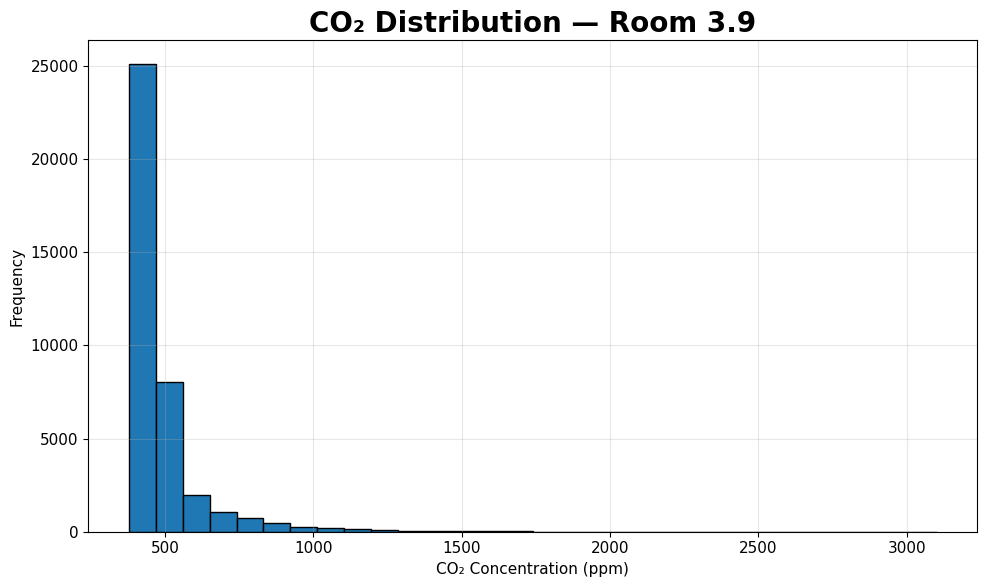

count    38307.00
mean       490.90
std        156.25
min        378.00
25%        419.00
50%        443.00
75%        495.00
max       3101.00
Name: co2, dtype: float64

Median   : 443.00
Variance : 24414.08
Skewness : 5.06
Saved: Figure_3_1_CO2_Distribution_Room_3_9.png


In [7]:
# FIGURE 3.1 — CO₂ DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["co2"],
    bins=30,
    edgecolor="black"
)

ax.set_title(
    "CO₂ Distribution — Room 3.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("CO₂ Concentration (ppm)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_3_1_CO2_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["co2"])

print(f"Saved: {file_name}")

## Temperature and Humidity Analysis

This section examines the distributions of indoor temperature and relative humidity in Room 3.9.

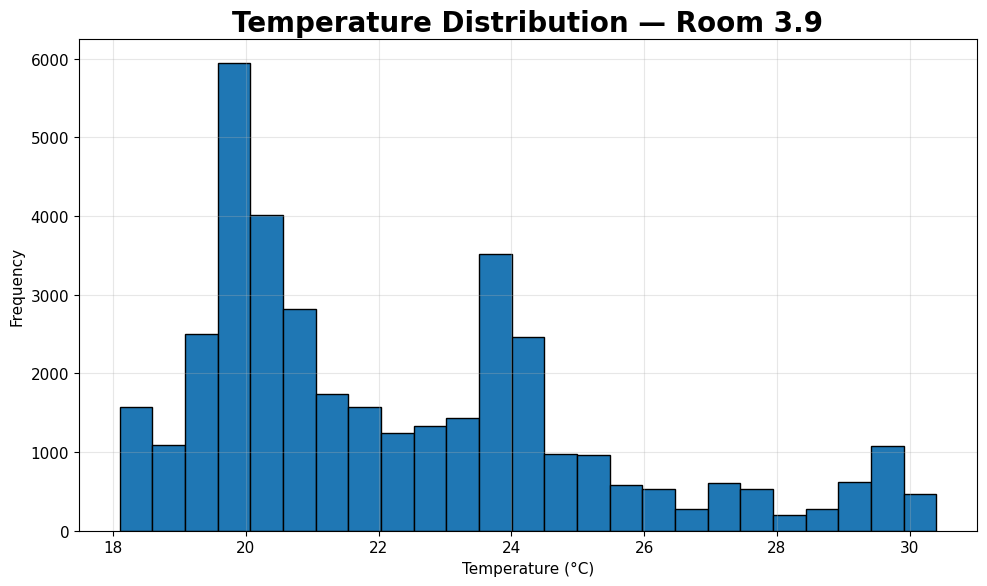

count    38307.00
mean        22.30
std          2.98
min         18.10
25%         20.00
50%         21.40
75%         24.00
max         30.40
Name: temperature, dtype: float64

Median   : 21.40
Variance : 8.90
Skewness : 0.92
Saved: Figure_3_2_Temperature_Distribution_Room_3_9.png


In [8]:
# FIGURE 3.2 — TEMPERATURE DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["temperature"],
    bins=25,
    edgecolor="black"
)

ax.set_title(
    "Temperature Distribution — Room 3.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_3_2_Temperature_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["temperature"])

print(f"Saved: {file_name}")

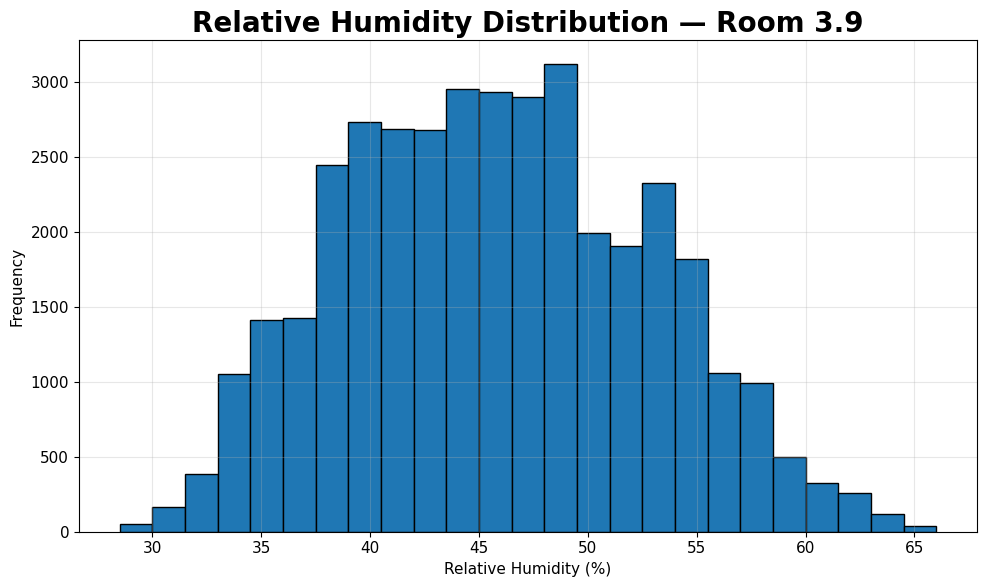

count    38307.00
mean        45.53
std          6.90
min         28.50
25%         40.00
50%         45.50
75%         50.50
max         66.00
Name: humidity, dtype: float64

Median   : 45.50
Variance : 47.60
Skewness : 0.15
Saved: Figure_3_3_Humidity_Distribution_Room_3_9.png


In [9]:
# FIGURE 3.3 — HUMIDITY DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["humidity"],
    bins=25,
    edgecolor="black"
)

ax.set_title(
    "Relative Humidity Distribution — Room 3.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_3_3_Humidity_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["humidity"])

print(f"Saved: {file_name}")

## Additional Sensor Variables

This section examines the light level, PIR motion detection, and window-state measurements recorded in Room 3.9.

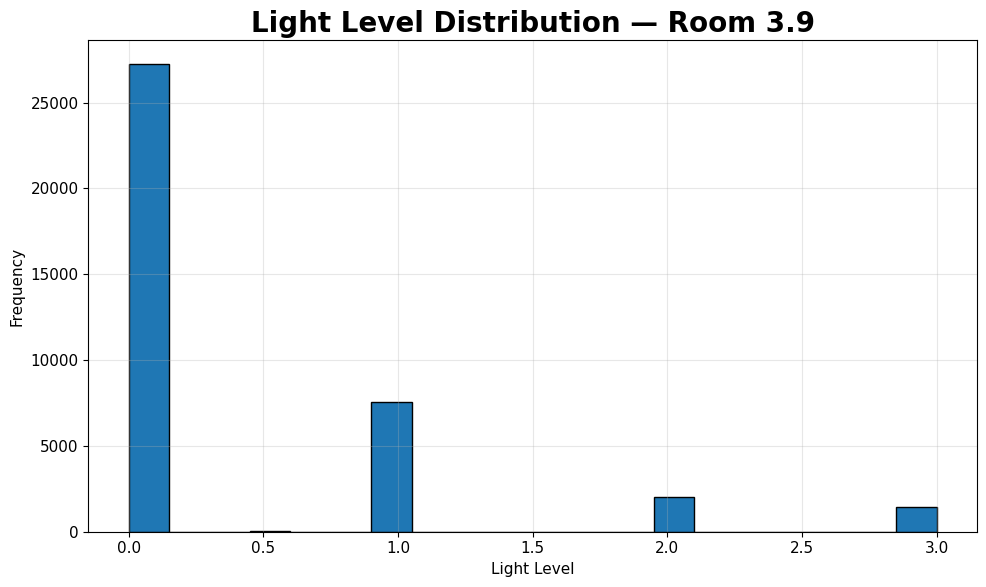

count    38307.00
mean         0.42
std          0.76
min          0.00
25%          0.00
50%          0.00
75%          1.00
max          3.00
Name: light_level, dtype: float64

Median   : 0.00
Variance : 0.58
Skewness : 1.95
Saved: Figure_3_4_Light_Level_Distribution_Room_3_9.png


In [10]:
# FIGURE 3.4 — LIGHT LEVEL DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["light_level"],
    bins=20,
    edgecolor="black"
)

ax.set_title(
    "Light Level Distribution — Room 3.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Light Level")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_3_4_Light_Level_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["light_level"])

print(f"Saved: {file_name}")

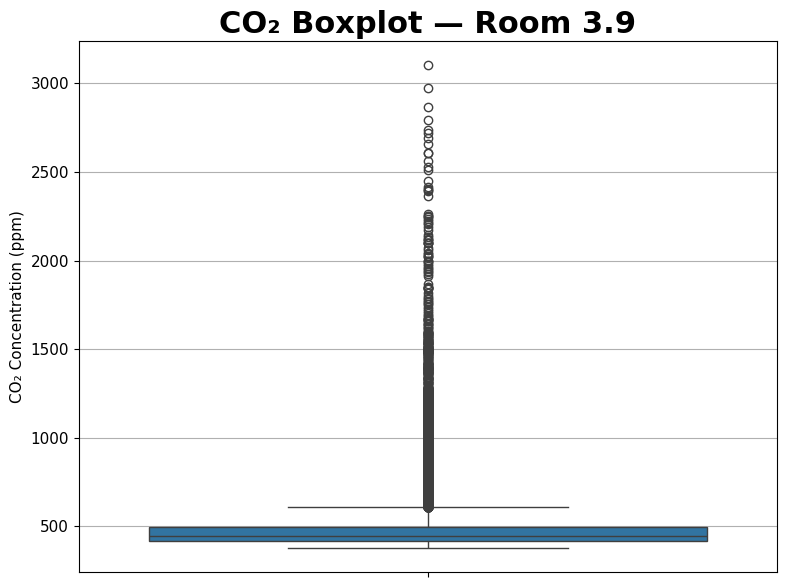

Saved: Figure_3_5_CO2_Boxplot_Room_3_9.png


In [11]:
# FIGURE 3.5 — CO₂ BOXPLOT


fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    y=df["co2"],
    ax=ax
)

ax.set_title(
    "CO₂ Boxplot — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_5_CO2_Boxplot_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [12]:
# PIR descriptive statistics
print_statistics(df["pir"])

count    38307.00
mean         0.04
std          0.20
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.00
Name: pir, dtype: float64

Median   : 0.00
Variance : 0.04
Skewness : 4.50


In [13]:
# PIR state distribution
pir_counts = (
    df["pir"]
    .value_counts()
    .sort_index()
    .rename_axis("pir")
    .to_frame("Count")
)

pir_counts["Percentage (%)"] = (
    pir_counts["Count"] / len(df) * 100
).round(2)

display(pir_counts)

,Count,Percentage (%)
pir,,
0,36658,95.7
1,1649,4.3


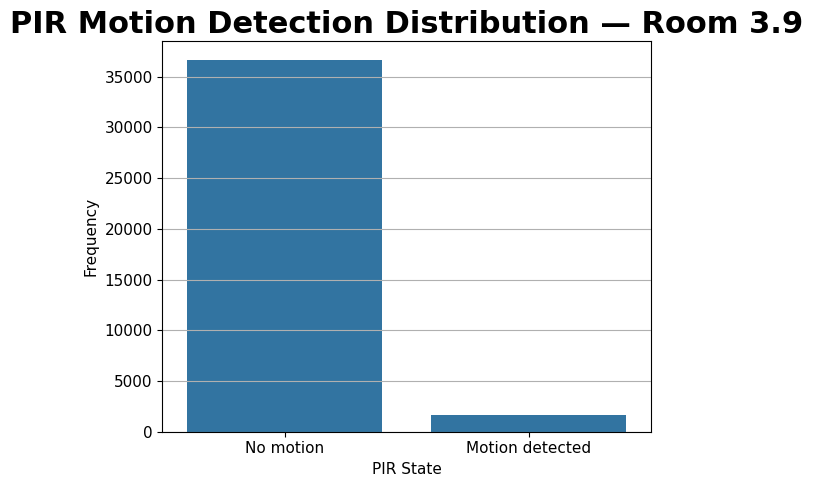

Saved: Figure_3_6_PIR_Distribution_Room_3_9.png


In [14]:
# FIGURE 3.6 — PIR MOTION DETECTION DISTRIBUTION


fig, ax = plt.subplots(figsize=(6, 5))

sns.countplot(
    data=df,
    x="pir",
    color="#1f77b4",
    ax=ax
)

ax.set_title(
    "PIR Motion Detection Distribution — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("PIR State")
ax.set_ylabel("Frequency")

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No motion", "Motion detected"]
)

plt.tight_layout()

file_name = "Figure_3_6_PIR_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [15]:
# Light level distribution
light_counts = (
    df["light_level"]
    .value_counts()
    .sort_index()
    .rename_axis("light_level")
    .to_frame("Count")
)

light_counts["Percentage (%)"] = (
    light_counts["Count"] / len(df) * 100
).round(2)

display(light_counts)

,Count,Percentage (%)
light_level,,
0.0,27258,71.16
0.5,22,0.06
1.0,7553,19.72
1.5,8,0.02
2.0,2018,5.27
2.5,2,0.01
3.0,1446,3.77


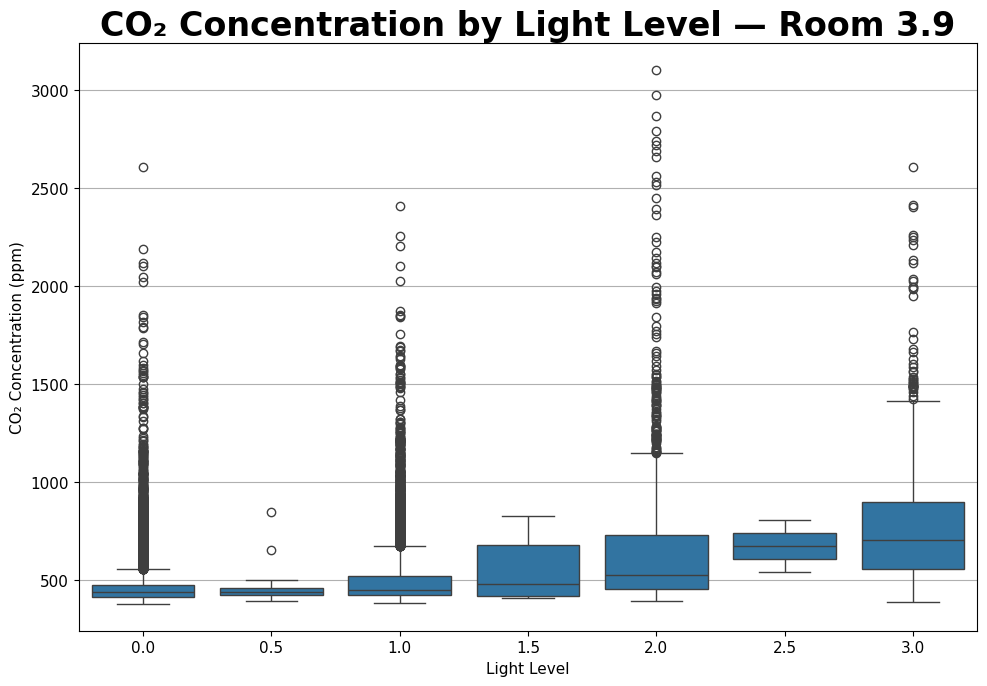

Saved: CO2_by_Light_Level_Room_3_9.png


In [16]:
# ADDITIONAL ANALYSIS — CO₂ BY LIGHT LEVEL


fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=df,
    x="light_level",
    y="co2",
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by Light Level — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Light Level")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "CO2_by_Light_Level_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [17]:
# LIGHT LEVEL CATEGORIZATION


df["light_category"] = pd.cut(
    df["light_level"],
    bins=[-0.01, 0.75, 1.75, 2.75, 3.01],
    labels=[
        "Level 0",
        "Level 1",
        "Level 2",
        "Level 3"
    ]
)

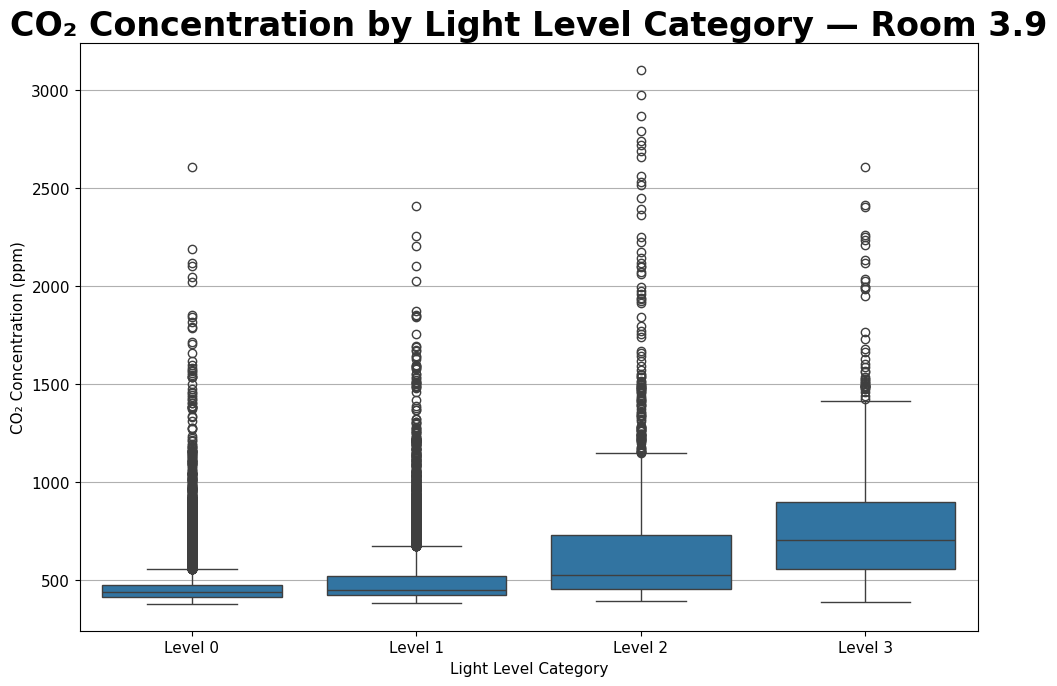

Saved: CO2_by_Light_Level_Category_Room_3_9.png


In [18]:
# ADDITIONAL ANALYSIS — CO₂ BY LIGHT LEVEL CATEGORY


fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=df,
    x="light_category",
    y="co2",
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by Light Level Category — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Light Level Category")
ax.set_ylabel("CO₂ Concentration (ppm)")

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(
    ["Level 0", "Level 1", "Level 2", "Level 3"]
)

plt.tight_layout()

file_name = "CO2_by_Light_Level_Category_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

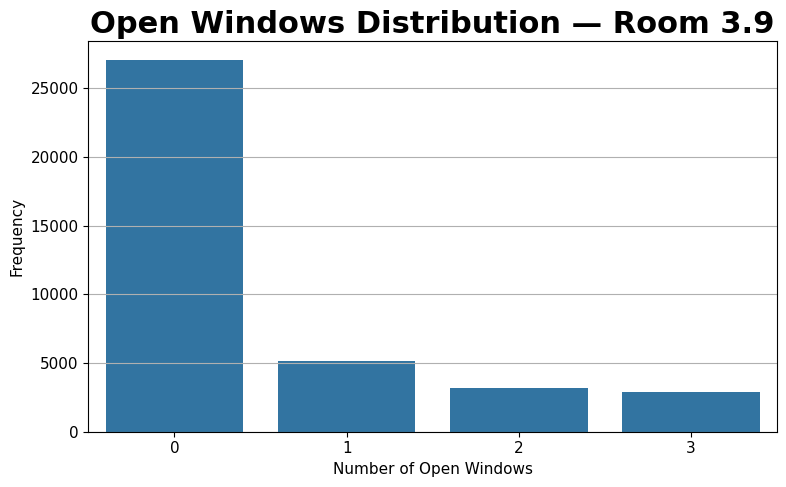

,Count,Percentage (%)
open_windows_all,,
0,27068,70.66
1,5124,13.38
2,3213,8.39
3,2902,7.58


count    38307.00
mean         0.53
std          0.93
min          0.00
25%          0.00
50%          0.00
75%          1.00
max          3.00
Name: open_windows_all, dtype: float64

Median   : 0.00
Variance : 0.87
Skewness : 1.62
Saved: Open_Windows_Distribution_Room_3_9.png


In [19]:
# ADDITIONAL ANALYSIS — OPEN WINDOWS DISTRIBUTION


fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="open_windows_all",
    ax=ax
)

ax.set_title(
    "Open Windows Distribution — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("Frequency")

plt.tight_layout()

file_name = "Open_Windows_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Count and percentage by number of open windows
open_windows_counts = (
    df["open_windows_all"]
    .value_counts()
    .sort_index()
    .rename_axis("open_windows_all")
    .to_frame("Count")
)

open_windows_counts["Percentage (%)"] = (
    open_windows_counts["Count"] / len(df) * 100
).round(2)

display(open_windows_counts)

print_statistics(df["open_windows_all"])

print(f"Saved: {file_name}")

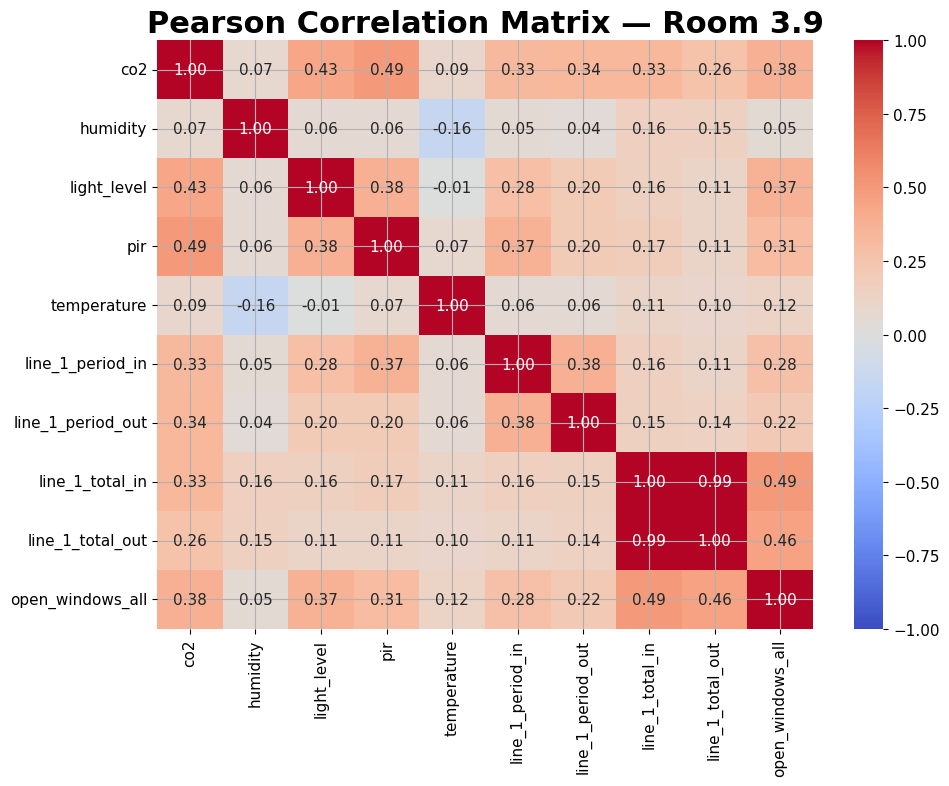

Saved: Pearson_Correlation_Matrix_Room_3_9.png


In [20]:
# ADDITIONAL ANALYSIS — PEARSON CORRELATION MATRIX


numeric_df = df.select_dtypes(include=np.number)

# Identify and exclude constant numeric columns
constant_cols = [
    col
    for col in numeric_df.columns
    if numeric_df[col].nunique() <= 1
]

corr = numeric_df.drop(columns=constant_cols).corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=ax
)

ax.set_title(
    "Pearson Correlation Matrix — Room 3.9",
    fontsize=22,
    weight="bold"
)

plt.tight_layout()

file_name = "Pearson_Correlation_Matrix_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [21]:
# FEATURE ENGINEERING — TRAFFIC


df["traffic"] = (
    df["line_1_period_in"] +
    df["line_1_period_out"]
)

print("Traffic feature created successfully.")

display(df.head())

Traffic feature created successfully.


,ts,co2,humidity,light_level,pir,temperature,co2_level,line_1_period_in,line_1_period_out,line_1_total_in,line_1_total_out,open_windows_all,light_category,traffic
0,2025-08-31 23:40:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0,Level 0,0
1,2025-08-31 23:50:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0,Level 0,0
2,2025-09-01 00:00:00,417.0,41.0,0.0,0,29.8,Low,0,0,0,0,0,Level 0,0
3,2025-09-01 00:10:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0,Level 0,0
4,2025-09-01 00:20:00,416.0,41.0,0.0,0,29.8,Low,0,0,0,0,0,Level 0,0


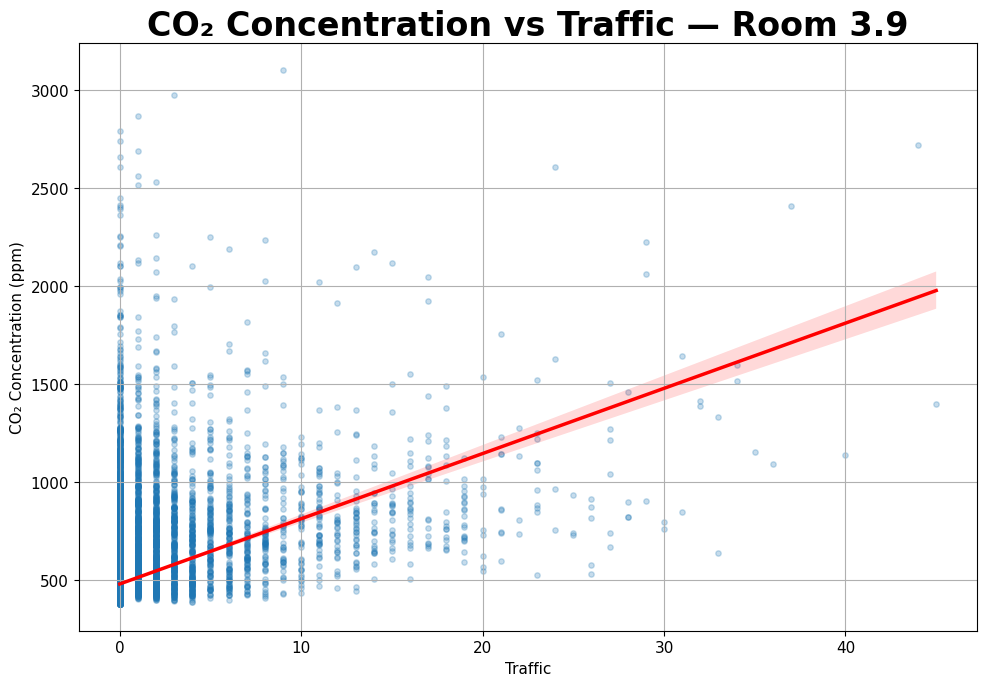

In [22]:
# FIGURE 3.7 — CO₂ VS TRAFFIC


fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=df,
    x="traffic",
    y="co2",
    scatter_kws={
        "alpha": 0.25,
        "s": 15
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Traffic — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Traffic")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_7_CO2_vs_Traffic_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

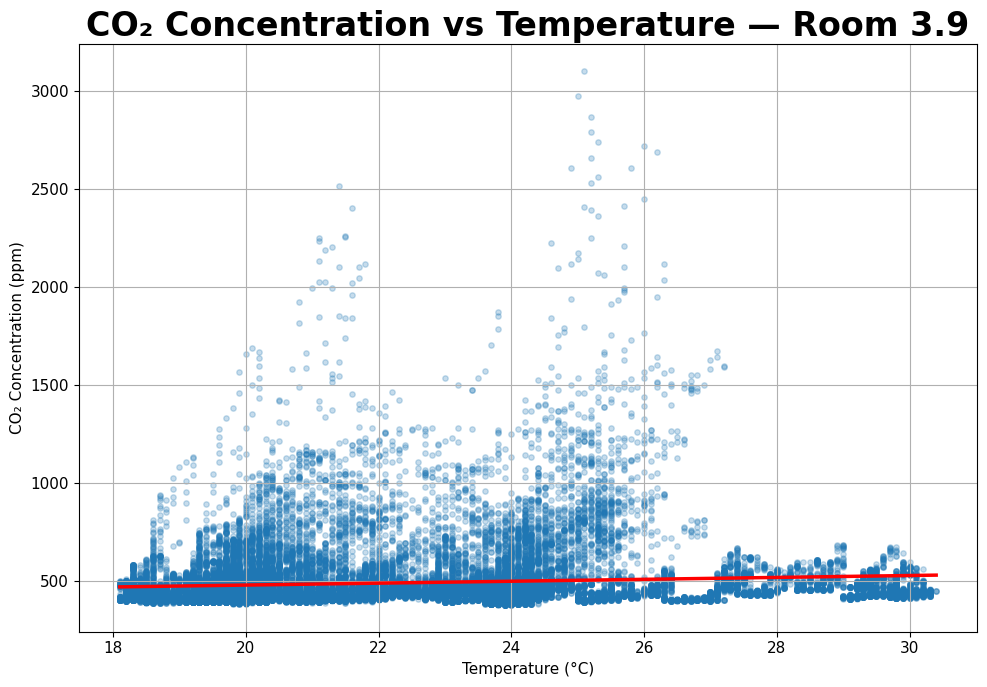

Saved: Figure_3_8_CO2_vs_Temperature_Room_3_9.png


In [23]:
# FIGURE 3.8 — CO₂ VS TEMPERATURE

fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=df,
    x="temperature",
    y="co2",
    scatter_kws={
        "alpha": 0.25,
        "s": 15
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Temperature — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_8_CO2_vs_Temperature_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

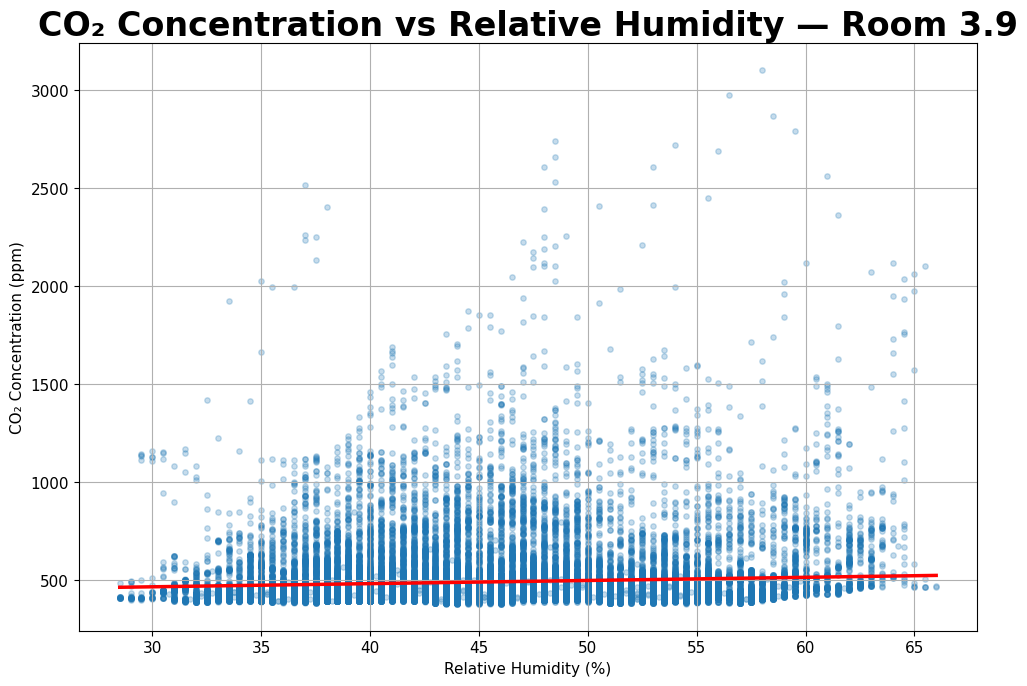

Saved: Figure_3_9_CO2_vs_Humidity_Room_3_9.png


In [24]:
# FIGURE 3.9 — CO₂ VS RELATIVE HUMIDITY


fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=df,
    x="humidity",
    y="co2",
    scatter_kws={
        "alpha": 0.25,
        "s": 15
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Relative Humidity — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_9_CO2_vs_Humidity_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

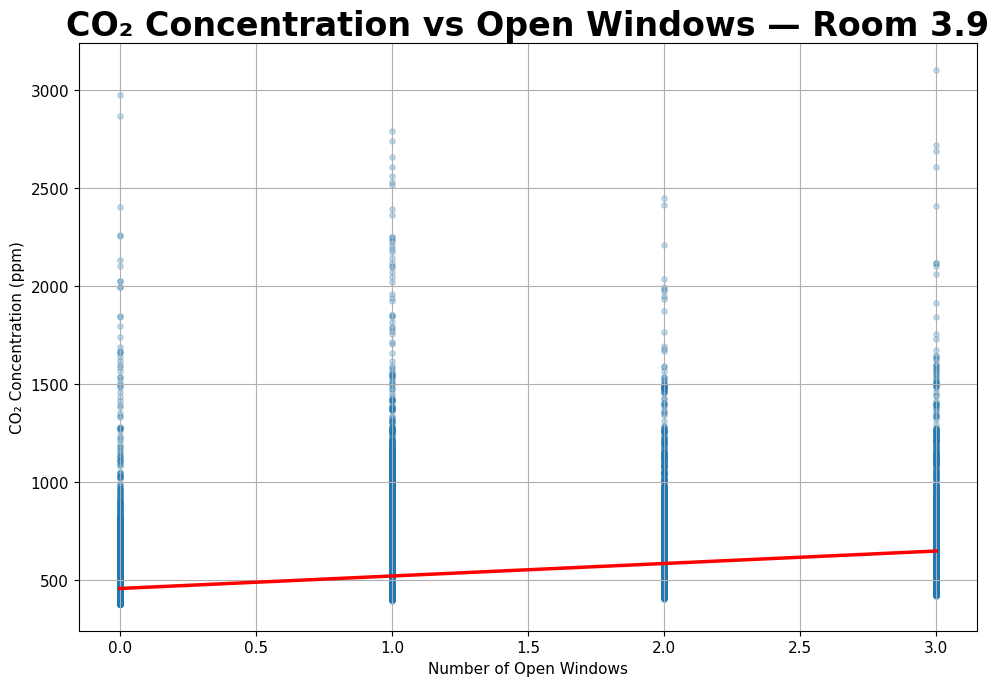

Saved: Figure_3_10_CO2_vs_Open_Windows_Room_3_9.png


In [25]:
# FIGURE 3.10 — CO₂ VS OPEN WINDOWS


fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=df,
    x="open_windows_all",
    y="co2",
    scatter_kws={
        "alpha": 0.25,
        "s": 15
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Open Windows — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_10_CO2_vs_Open_Windows_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

## Temporal Analysis

This section examines the temporal evolution and recurring patterns of CO₂ concentration in Room 3.9.

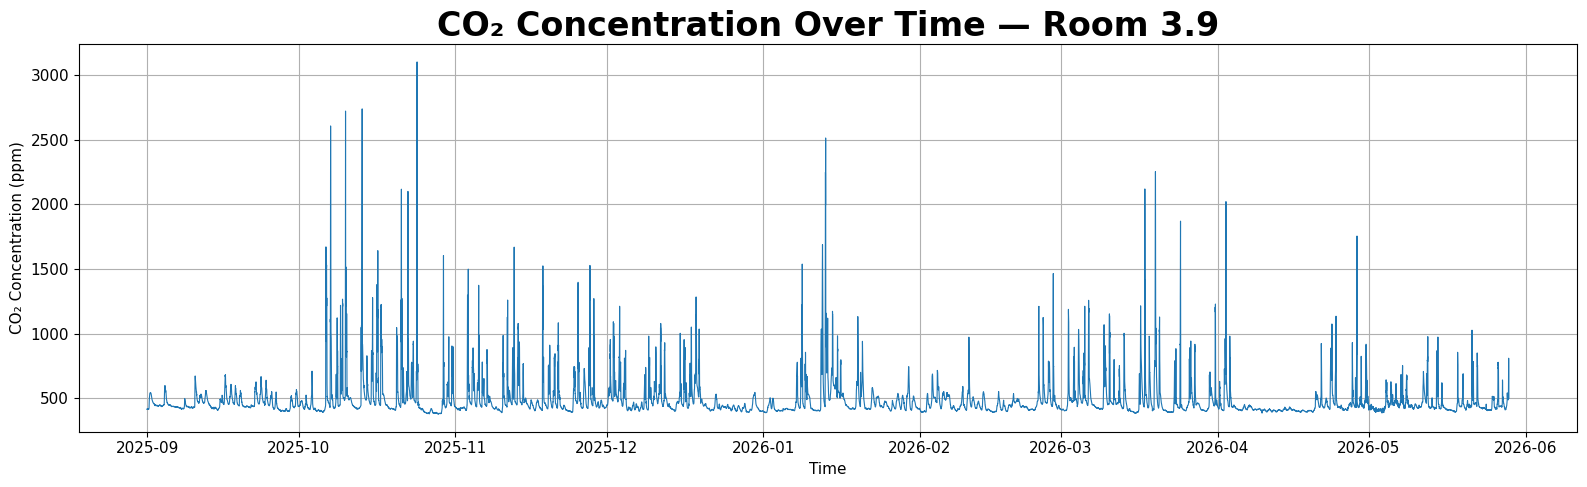

Saved: Figure_3_11_CO2_TimeSeries_Room_3_9.png


In [26]:
# FIGURE 3.11 — CO₂ TIME SERIES


fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df["ts"],
    df["co2"],
    linewidth=0.8
)

ax.set_title(
    "CO₂ Concentration Over Time — Room 3.9",
    fontsize=24,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_3_11_CO2_TimeSeries_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

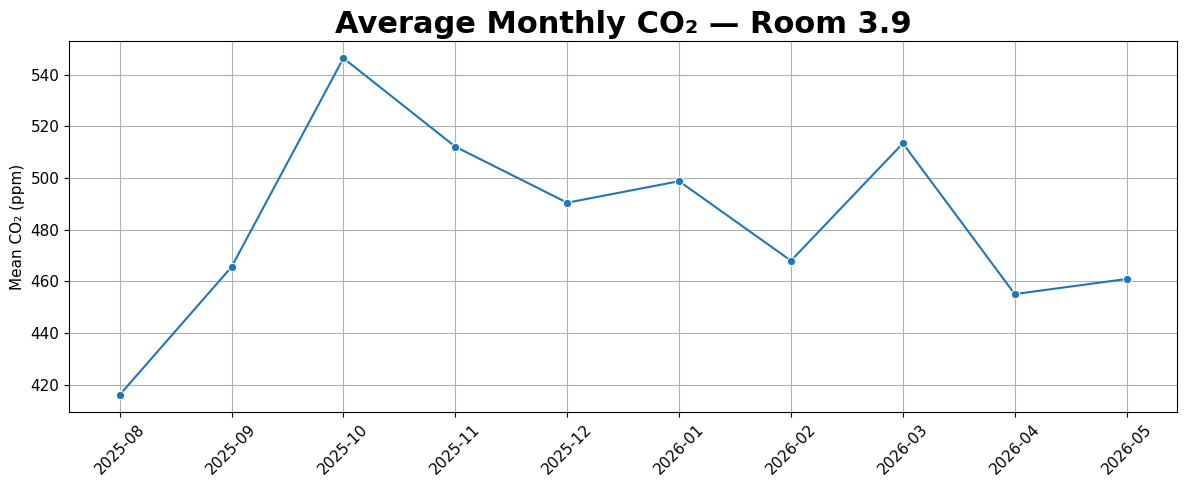

Saved: Figure_3_12_Monthly_CO2_Room_3_9.png


In [27]:
# FIGURE 3.12 — AVERAGE MONTHLY CO₂

# Create month feature for temporal analysis
df["month"] = df["ts"].dt.to_period("M").astype(str)

monthly = (
    df.groupby("month")["co2"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x="month",
    y="co2",
    marker="o",
    ax=ax
)

ax.tick_params(axis="x", rotation=45)

ax.set_title(
    "Average Monthly CO₂ — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Mean CO₂ (ppm)")

plt.tight_layout()

file_name = "Figure_3_12_Monthly_CO2_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

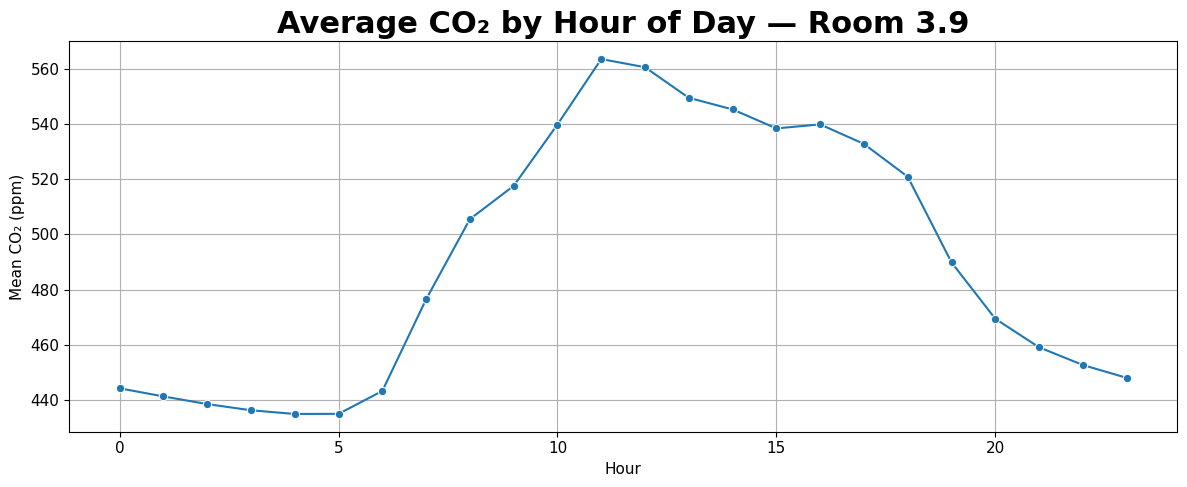

Saved: Figure_3_13_Hourly_CO2_Room_3_9.png


In [28]:
# FIGURE 3.13 — AVERAGE CO₂ BY HOUR OF DAY


# Create hour feature for temporal analysis
df["hour"] = df["ts"].dt.hour

hourly = (
    df.groupby("hour")["co2"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=hourly,
    x="hour",
    y="co2",
    marker="o",
    ax=ax
)

ax.set_title(
    "Average CO₂ by Hour of Day — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean CO₂ (ppm)")

plt.tight_layout()

file_name = "Figure_3_13_Hourly_CO2_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

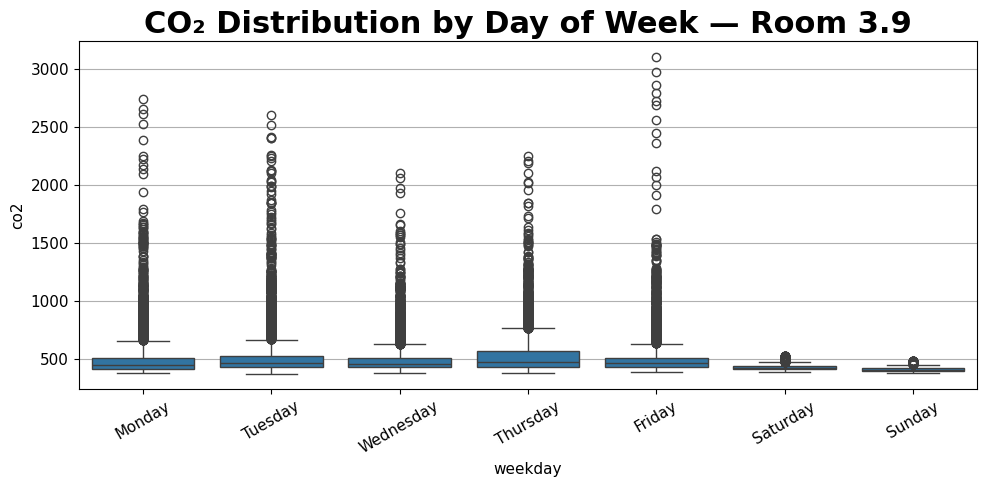

Saved: Figure_3_14_CO2_Weekday_Room_3_9.png


In [29]:
# FIGURE 3.14 — CO₂ DISTRIBUTION BY DAY OF WEEK


# Create weekday feature for temporal analysis
df["weekday"] = df["ts"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="weekday",
    y="co2",
    order=weekday_order,
    ax=ax
)

ax.set_title(
    "CO₂ Distribution by Day of Week — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()

file_name = "Figure_3_14_CO2_Weekday_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

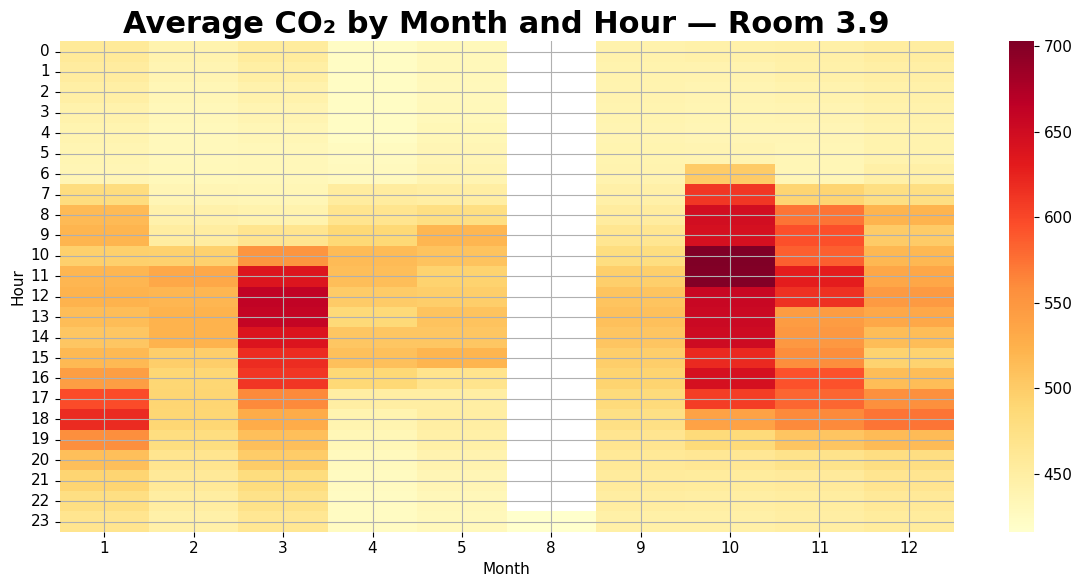

Saved: Figure_3_15_CO2_Heatmap_Room_3_9.png


In [30]:
# FIGURE 3.15 — AVERAGE CO₂ BY MONTH AND HOUR


co2_month_hour = df.pivot_table(
    values="co2",
    index=df["ts"].dt.hour,
    columns=df["ts"].dt.month,
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    co2_month_hour,
    cmap="YlOrRd",
    ax=ax
)

ax.set_title(
    "Average CO₂ by Month and Hour — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Hour")

plt.tight_layout()

file_name = "Figure_3_15_CO2_Heatmap_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

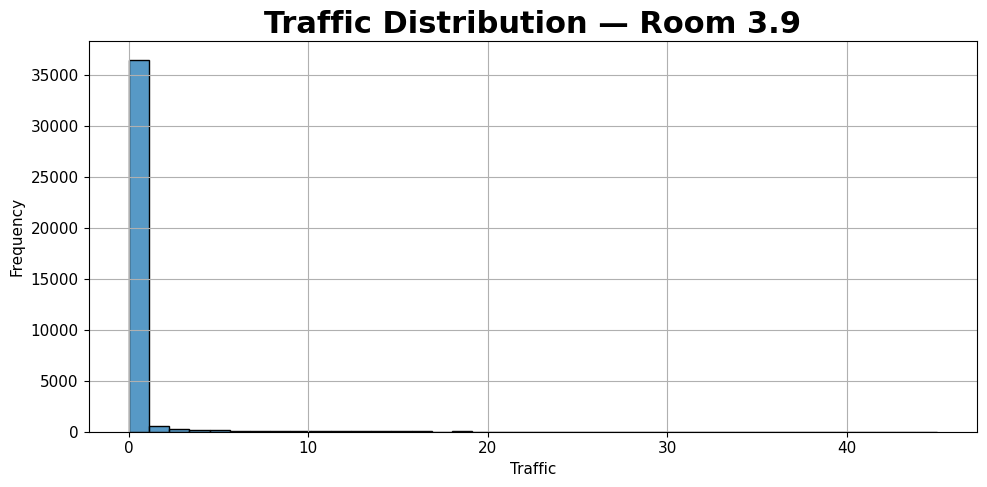

Saved: Figure_3_16_Traffic_Distribution_Room_3_9.png


In [31]:
# FIGURE 3.16 — TRAFFIC DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df["traffic"],
    bins=40,
    ax=ax
)

ax.set_title(
    "Traffic Distribution — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("Traffic")
ax.set_ylabel("Frequency")

plt.tight_layout()

file_name = "Figure_3_16_Traffic_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

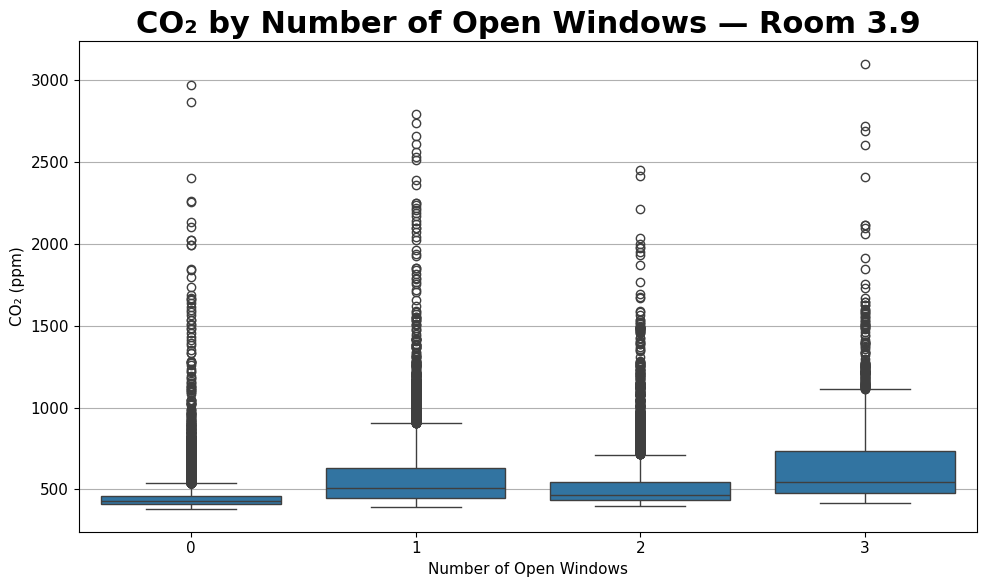

Saved: Figure_3_17_CO2_OpenWindows_Boxplot_Room_3_9.png


In [32]:
# FIGURE 3.17 — CO₂ BY NUMBER OF OPEN WINDOWS


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="open_windows_all",
    y="co2",
    ax=ax
)

ax.set_title(
    "CO₂ by Number of Open Windows — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("CO₂ (ppm)")

plt.tight_layout()

file_name = "Figure_3_17_CO2_OpenWindows_Boxplot_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

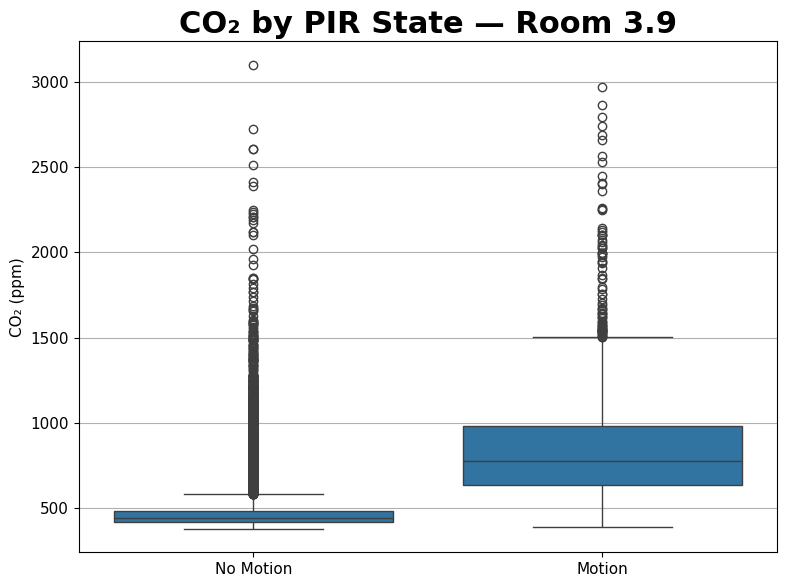

Saved: Figure_3_18_CO2_PIR_Boxplot_Room_3_9.png


In [33]:
# FIGURE 3.18 — CO₂ BY PIR STATE


fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="pir",
    y="co2",
    ax=ax
)

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No Motion", "Motion"]
)

ax.set_title(
    "CO₂ by PIR State — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("CO₂ (ppm)")

plt.tight_layout()

file_name = "Figure_3_18_CO2_PIR_Boxplot_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

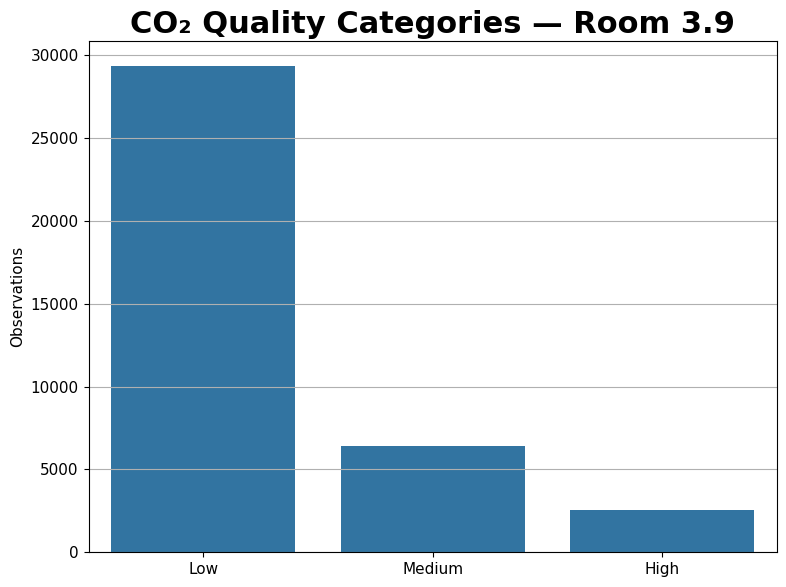

Saved: Figure_3_19_CO2_Level_Distribution_Room_3_9.png


In [34]:
# FIGURE 3.19 — CO₂ QUALITY CATEGORIES


fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    data=df,
    x="co2_level",
    ax=ax
)

ax.set_title(
    "CO₂ Quality Categories — Room 3.9",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Observations")

plt.tight_layout()

file_name = "Figure_3_19_CO2_Level_Distribution_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

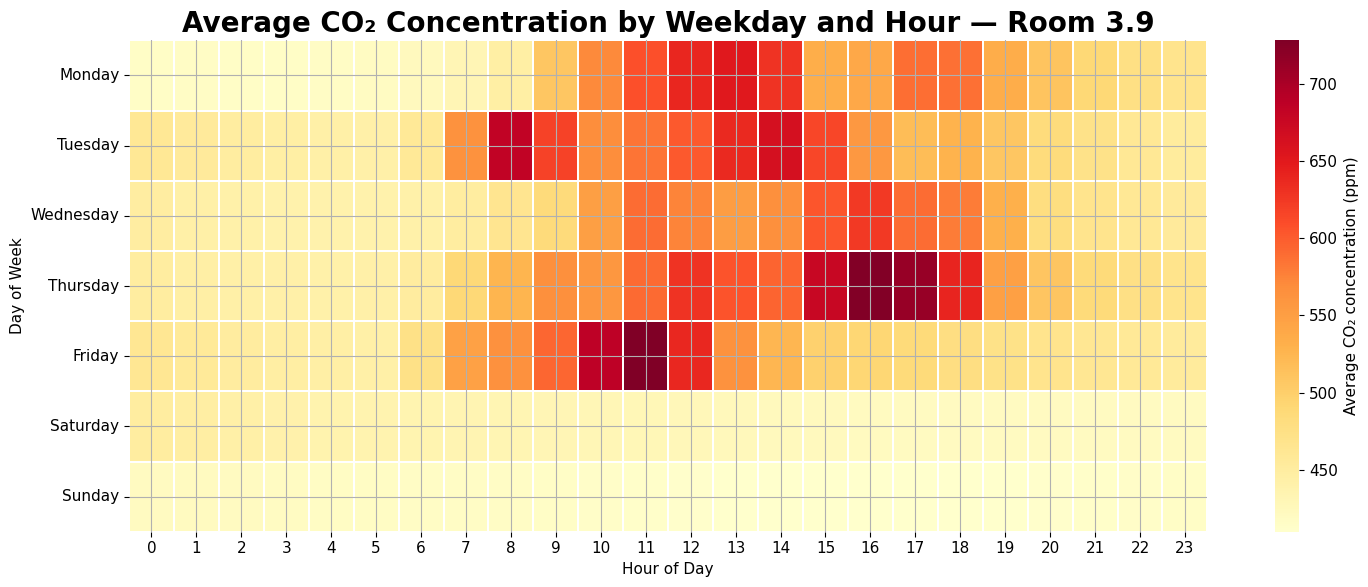

Saved: CO2_Weekday_Hour_Heatmap_Room_3_9.png


In [35]:
# ADDITIONAL ANALYSIS — CO₂ BY WEEKDAY AND HOUR

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

co2_weekday_hour = (
    df.pivot_table(
        index="weekday",
        columns="hour",
        values="co2",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    co2_weekday_hour,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Average CO₂ concentration (ppm)"
    },
    ax=ax
)

ax.set_title(
    "Average CO₂ Concentration by Weekday and Hour — Room 3.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()

file_name = "CO2_Weekday_Hour_Heatmap_Room_3_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [37]:
# FINAL CLEANUP AND VALIDATION


# Remove temporary EDA features
temporary_columns = [
    "traffic",
    "light_category",
    "month",
    "hour",
    "weekday"
]

df.drop(
    columns=[
        col for col in temporary_columns
        if col in df.columns
    ],
    inplace=True
)

# Final validation
assert df.shape[0] == 38307
assert df.shape[1] == 12
assert df["ts"].duplicated().sum() == 0
assert df.isna().sum().sum() == 0


print("ROOM 3.9 EDA — FINAL VALIDATION")


print("\nRoom 3.9 EDA completed successfully.")
print(f"Rows: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"Time range: {df['ts'].min()} → {df['ts'].max()}")
print(f"Duplicate timestamps: {df['ts'].duplicated().sum()}")
print(f"Missing values: {df.isna().sum().sum()}")

ROOM 3.9 EDA — FINAL VALIDATION

Room 3.9 EDA completed successfully.
Rows: 38307
Columns: 12
Time range: 2025-08-31 23:40:00 → 2026-05-28 16:50:00
Duplicate timestamps: 0
Missing values: 0
